Département de génie électrique - Polytechnique Montréal

Analyse des signaux - ELE2700

TP3 version 4.0: A2025

---

Numéro d'équipe: #102

Noms, prénoms et matricules:

Machraoui, Simon : 2487824

Beaumier, Édouard : 2087482

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## $\color{#03fc9d}{\textbf{Exercice 2, devoir (10pt/20):}}$

**Objectif : Dans cette section, nous découvrirons l'effet du fenêtrage et de la fuite spectrale sur les signaux idéaux.**

# <font color='green'> Introduction au fenêtrage et à la fuite spectrale </font>

Dans le domaine du traitement des signaux, surtout lors de l'utilisation de la transformée de Fourier discrète, le fenêtrage est une pratique courante. Tout signal de durée finie, comme le *chirp* analysé jusqu'à présent, peut être considéré comme un signal infini idéal multiplié par une fenêtre rectangulaire. Cette multiplication par une fenêtre rectangulaire introduit inévitablement une certaine fuite spectrale due aux discontinuités abruptes en début et fin de signal. En effet, une discontinuité soudaine dans le temps se manifeste par une dispersion dans le domaine fréquentiel, ce qui résulte en une fuite spectrale. Ceci provient du principe d'incertitude en analyse des signaux.

La technique de fenêtrage consiste donc à multiplier le signal par une "fenêtre" spécifique, souvent différente de la rectangulaire, et qui diminue plus graduellement vers zéro à ses extrémités. En atténuant le signal de cette manière, on peut réduire les discontinuités artificielles et, par conséquent, contrôler et atténuer le phénomène de fuite spectrale qui engendre sinon l'apparition de fréquences qui n'existent pas réellement dans le signal, rendant difficile l'identification des véritables composantes fréquentielles.

Différents types de fenêtres existent, chacune ayant ses propres caractéristiques et avantages. Celle de Hamming, par exemple, est conçue pour réduire spécifiquement la fuite spectrale tout en conservant une largeur de bande de résolution acceptable. Elle sera utilisée dans le présent exercice.

Nous approfondirons le concept de fenêtrage, son importance en traitement du signal, et les nuances de la fuite spectrale dans le Chapitre 7.

Pour en apprendre plus sur le fenêtrage: https://en.wikipedia.org/wiki/Window_function#A_list_of_window_functions

Pour en apprendre plus sur la fuite spectrale: https://en.wikipedia.org/wiki/Spectral_leakage

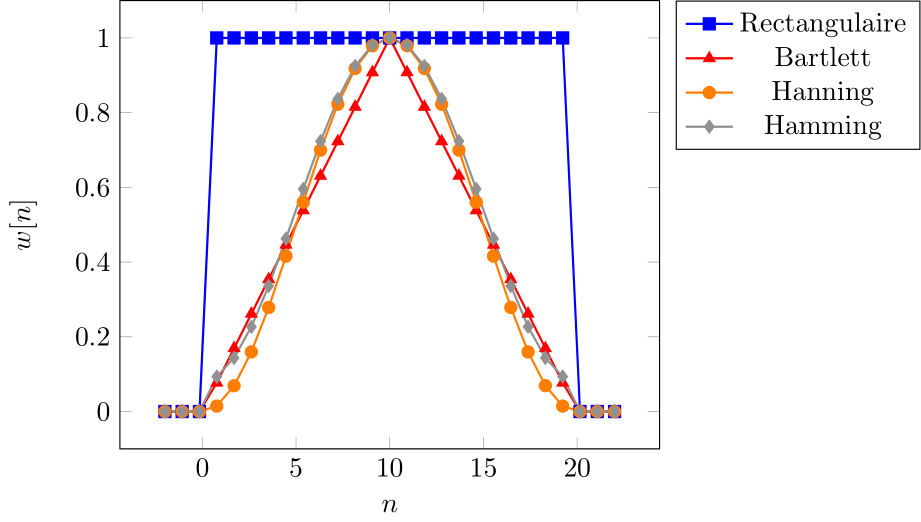


$\color{orange}{\text{a) [code]}}$ Appliquer une fenêtre de Hamming aux signaux *chirp exponentiel* et sinus générés à l'exercice 0 à l'aide de la fonction `numpy.hamming`. Visualiser les signaux dans le domaine temporel avant et après l'application de la fenêtre. $\color{red}{\textbf{(2pt/20)}}$

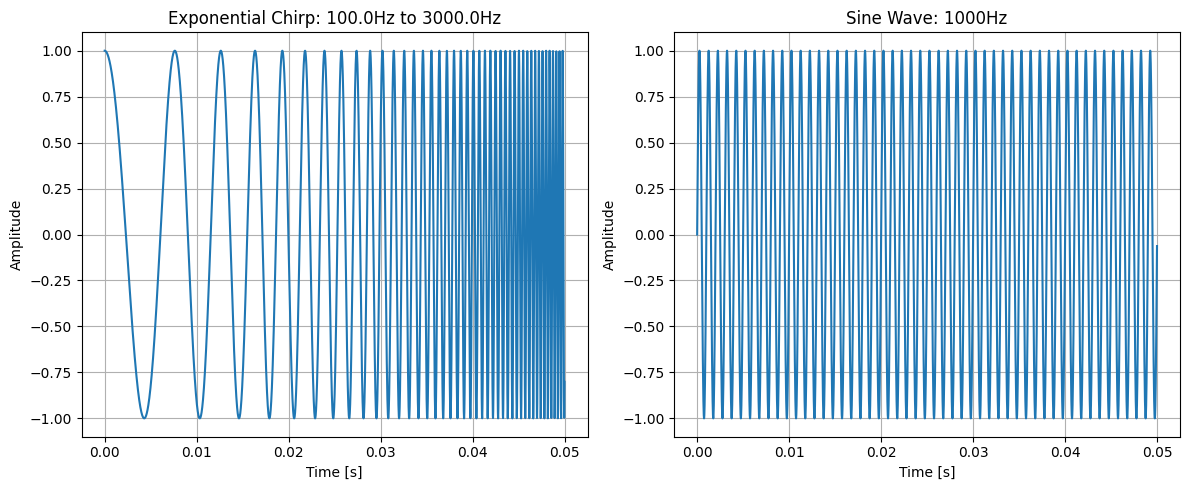

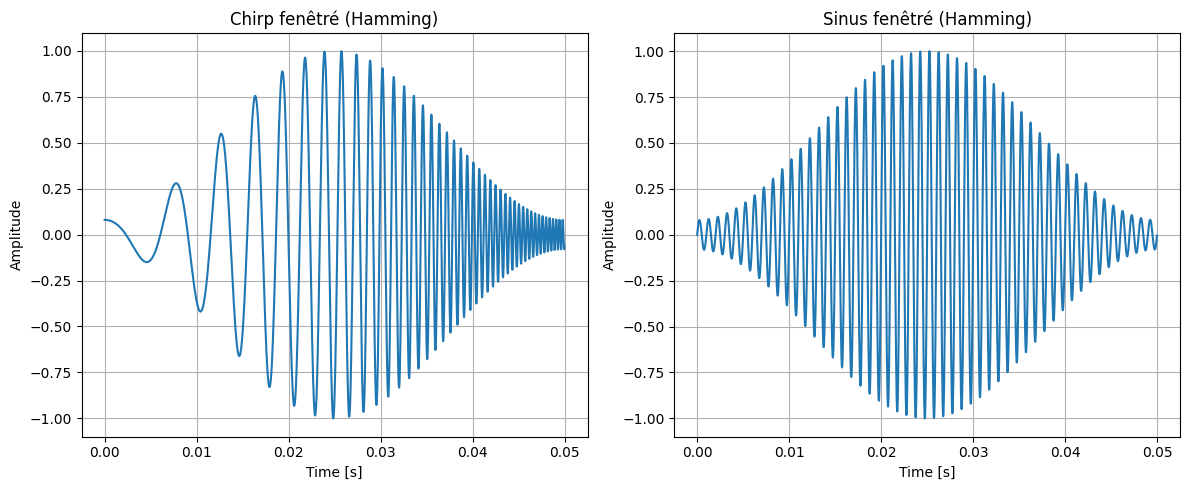

In [45]:
# Écrire votre code ici pour (a)

import numpy as np
import matplotlib.pyplot as plt

# Affichage des signaux
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t_exp, exp_chirp)
plt.title(f"Exponential Chirp: {f_start}Hz to {f_end}Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

f_sine = 1000  # 1 kHz

plt.subplot(1,2,2)
plt.plot(t, sine)
plt.title(f"Sine Wave: {f_sine}Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


# Fenêtres de Hamming
window_chirp = np.hamming(len(exp_chirp))
window_sine = np.hamming(len(sine))

# Signaux fenêtrés
chirp_windowed = exp_chirp * window_chirp
sine_windowed = sine * window_sine

# Affichage
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t_exp, chirp_windowed)
plt.title("Chirp fenêtré (Hamming)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, sine_windowed)
plt.title("Sinus fenêtré (Hamming)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


$\color{orange}{\text{b) [code]}}$ Réaliser à nouveau la transformée de Fourier des signaux fenêtrés et visualiser les résultats. $\color{red}{\textbf{(1pt/20)}}$

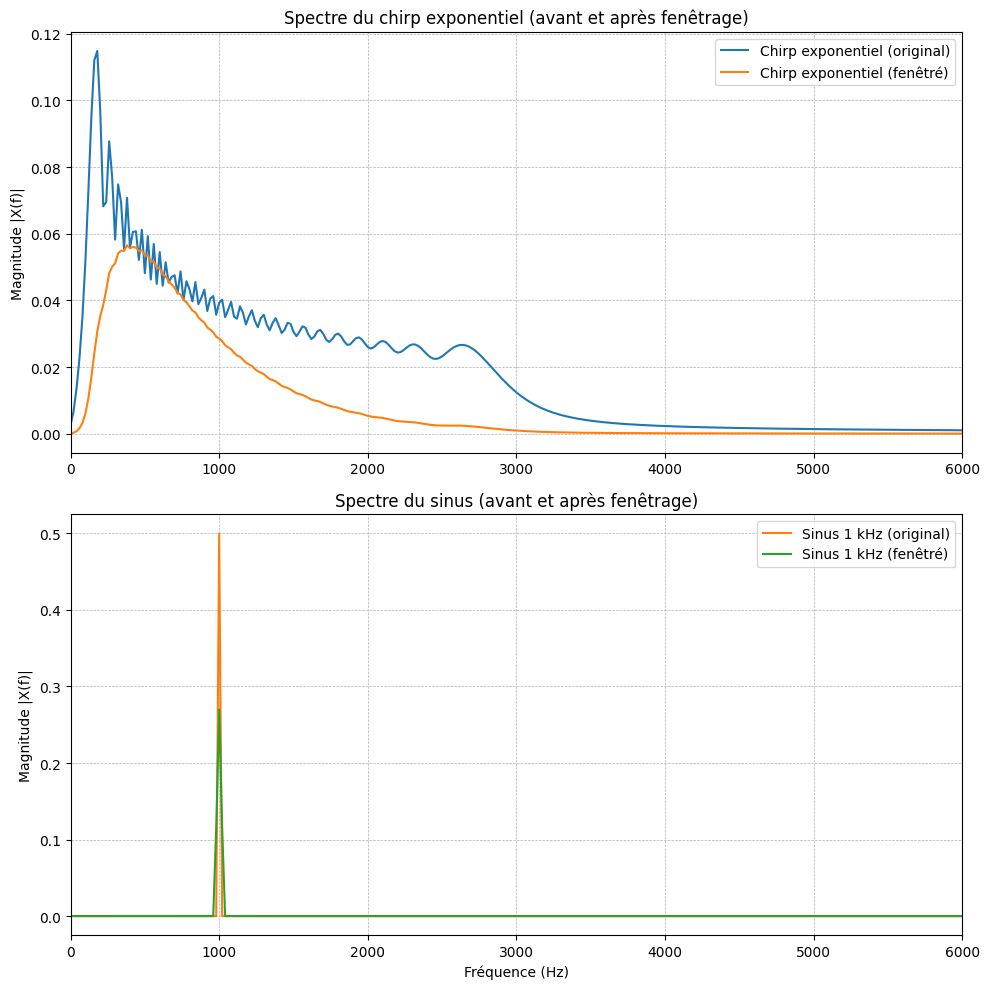

In [46]:
# Écrire votre code ici pour (b)

from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import numpy as np

# --- FFT ---
spectrum_chirp = fft(exp_chirp, norm='forward')
spectrum_chirp_win = fft(chirp_windowed, norm='forward')
spectrum_sine = fft(sine, norm='forward')
spectrum_sine_win = fft(sine_windowed, norm='forward')

# --- Axe des fréquences ---
freqs_chirp = fftfreq(len(t_exp), 1/fs)
freqs_sine = fftfreq(len(t), 1/fs)

# --- Masques pour fréquences positives et < 6000 Hz ---
mask_chirp = (freqs_chirp >= 0) & (freqs_chirp <= 6000)
mask_chirp_win = (freqs_chirp >= 0) & (freqs_chirp <= 6000)
mask_sine = (freqs_sine >= 0) & (freqs_sine <= 6000)
mask_sine_win = (freqs_sine >= 0) & (freqs_sine <= 6000)

# --- Affichage des spectres ---
plt.figure(figsize=(10, 10))

# Chirp exponentiel
plt.subplot(2, 1, 1)
plt.plot(freqs_chirp[mask_chirp], np.abs(spectrum_chirp[mask_chirp]), label='Chirp exponentiel (original)')
plt.plot(freqs_chirp[mask_chirp_win], np.abs(spectrum_chirp_win[mask_chirp_win]), label='Chirp exponentiel (fenêtré)')
plt.ylabel('Magnitude |X(f)|')
plt.title('Spectre du chirp exponentiel (avant et après fenêtrage)')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

# Sinus simple
plt.subplot(2, 1, 2)
plt.plot(freqs_sine[mask_sine], np.abs(spectrum_sine[mask_sine]), color='C1', label='Sinus 1 kHz (original)')
plt.plot(freqs_sine[mask_sine_win], np.abs(spectrum_sine_win[mask_sine_win]), color='C2', label='Sinus 1 kHz (fenêtré)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Magnitude |X(f)|')
plt.title('Spectre du sinus (avant et après fenêtrage)')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


$\color{orange}{\text{c) [code]}}$ Injecter le *chirp exponentiel* fenêtré dans une nouvelle boîte noire, `blackbox_tp3.blackbox2` et en faire l'analyse spectrale.  $\color{red}{\textbf{(2pt/20)}}$

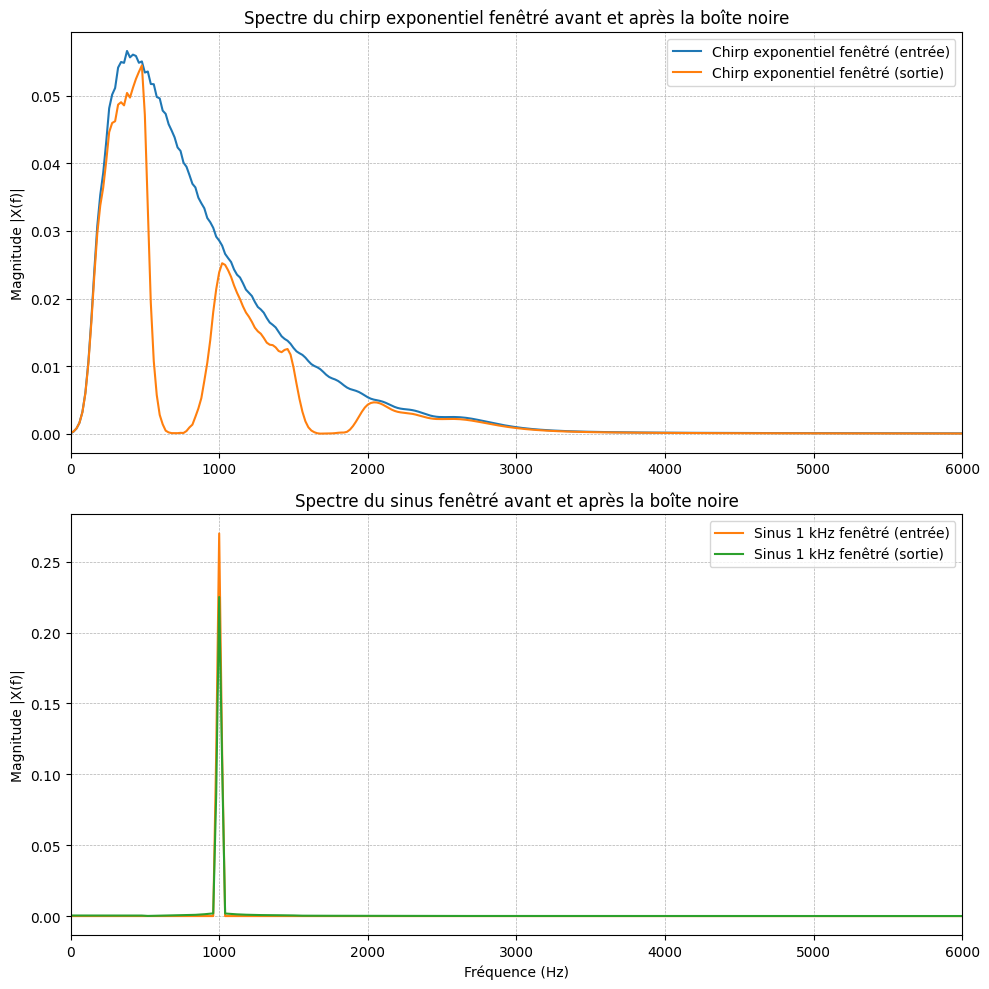

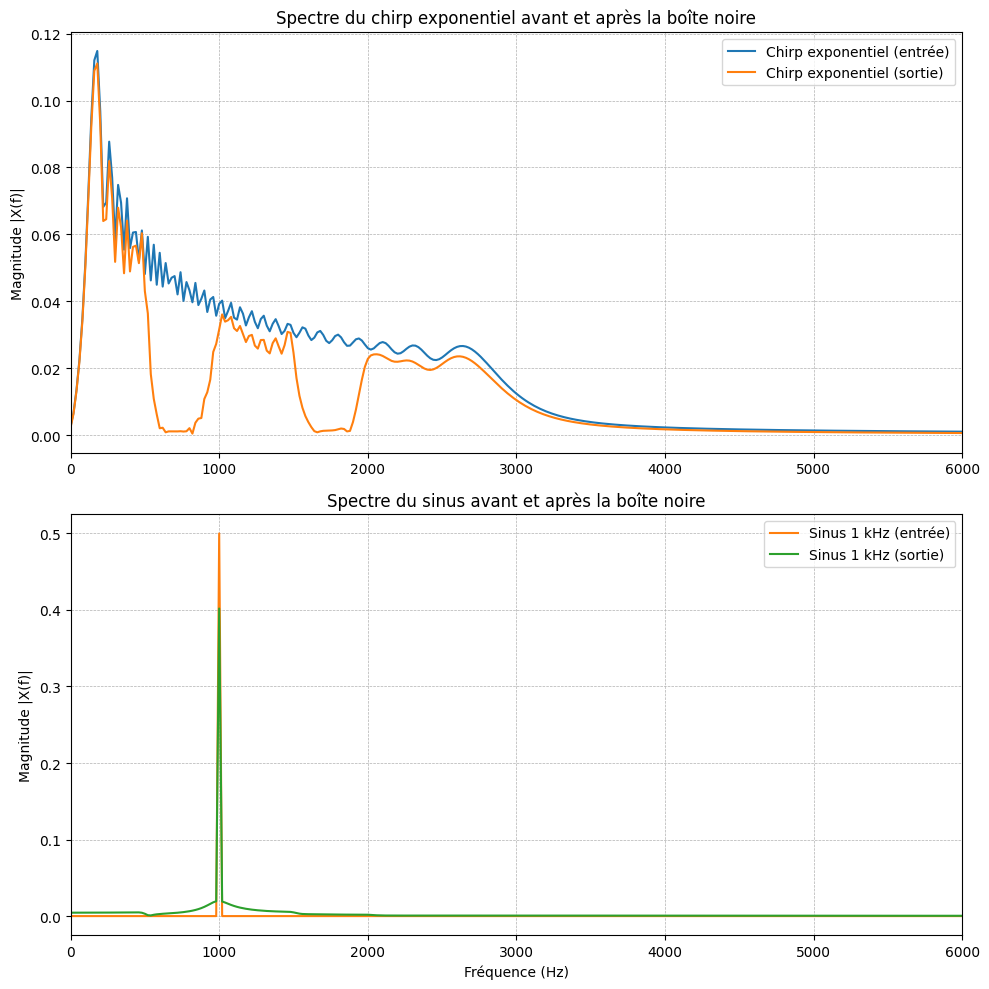

In [48]:
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import blackbox_tp3
import numpy as np

Te = 1.0 / fs

# --- Sorties de la boîte noire ---
output_chirp = blackbox_tp3.blackbox2(chirp_windowed.astype(np.float64), float(fs))
output_sine = blackbox_tp3.blackbox2(sine_windowed.astype(np.float64), float(fs))

# --- FFT du chirp exponentiel ---
spectrum_chirp = fft(chirp_windowed, norm='forward')
spectrum_output_chirp = fft(output_chirp, norm='forward')
freqs_chirp = fftfreq(chirp_windowed.size, Te)
freqs_output_chirp = fftfreq(output_chirp.size, Te)

# --- FFT du sinus ---
spectrum_sine = fft(sine_windowed, norm='forward')
spectrum_output_sine = fft(output_sine, norm='forward')
freqs_sine = fftfreq(sine_windowed.size, Te)
freqs_output_sine = fftfreq(output_sine.size, Te)

# --- Masques pour fréquences positives et jusqu’à 6000 Hz ---
mask_chirp = (freqs_chirp >= 0) & (freqs_chirp <= 6000)
mask_output_chirp = (freqs_output_chirp >= 0) & (freqs_output_chirp <= 6000)
mask_sine = (freqs_sine >= 0) & (freqs_sine <= 6000)
mask_output_sine = (freqs_output_sine >= 0) & (freqs_output_sine <= 6000)

# --- Affichage des spectres ---
plt.figure(figsize=(10, 10))

# Chirp exp
plt.subplot(2, 1, 1)
plt.plot(freqs_chirp[mask_chirp], np.abs(spectrum_chirp[mask_chirp]), label='Chirp exponentiel fenêtré (entrée)')
plt.plot(freqs_output_chirp[mask_output_chirp], np.abs(spectrum_output_chirp[mask_output_chirp]), label='Chirp exponentiel fenêtré (sortie)')
plt.ylabel('Magnitude |X(f)|')
plt.title('Spectre du chirp exponentiel fenêtré avant et après la boîte noire')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

# Sinus
plt.subplot(2, 1, 2)
plt.plot(freqs_sine[mask_sine], np.abs(spectrum_sine[mask_sine]), color='C1', label='Sinus 1 kHz fenêtré (entrée)')
plt.plot(freqs_output_sine[mask_output_sine], np.abs(spectrum_output_sine[mask_output_sine]), color='C2', label='Sinus 1 kHz fenêtré (sortie)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Magnitude |X(f)|')
plt.title('Spectre du sinus fenêtré avant et après la boîte noire')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()





# -----------------------------------------
#   ajouté pour répondre à la question e
# -----------------------------------------


# --- Sorties de la boîte noire ---
output_chirp = blackbox_tp3.blackbox2(exp_chirp.astype(np.float64), float(fs))
output_sine = blackbox_tp3.blackbox2(sine.astype(np.float64), float(fs))

# --- FFT du chirp exponentiel ---
spectrum_chirp = fft(exp_chirp, norm='forward')
spectrum_output_chirp = fft(output_chirp, norm='forward')
freqs_chirp = fftfreq(exp_chirp.size, Te)
freqs_output_chirp = fftfreq(output_chirp.size, Te)

# --- FFT du sinus ---
spectrum_sine = fft(sine, norm='forward')
spectrum_output_sine = fft(output_sine, norm='forward')
freqs_sine = fftfreq(sine.size, Te)
freqs_output_sine = fftfreq(output_sine.size, Te)

# --- Masques pour fréquences positives et jusqu’à 6000 Hz ---
mask_chirp = (freqs_chirp >= 0) & (freqs_chirp <= 6000)
mask_output_chirp = (freqs_output_chirp >= 0) & (freqs_output_chirp <= 6000)
mask_sine = (freqs_sine >= 0) & (freqs_sine <= 6000)
mask_output_sine = (freqs_output_sine >= 0) & (freqs_output_sine <= 6000)

# --- Affichage des spectres ---
plt.figure(figsize=(10, 10))

# Chirp exp
plt.subplot(2, 1, 1)
plt.plot(freqs_chirp[mask_chirp], np.abs(spectrum_chirp[mask_chirp]), label='Chirp exponentiel (entrée)')
plt.plot(freqs_output_chirp[mask_output_chirp], np.abs(spectrum_output_chirp[mask_output_chirp]), label='Chirp exponentiel (sortie)')
plt.ylabel('Magnitude |X(f)|')
plt.title('Spectre du chirp exponentiel avant et après la boîte noire')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

# Sinus
plt.subplot(2, 1, 2)
plt.plot(freqs_sine[mask_sine], np.abs(spectrum_sine[mask_sine]), color='C1', label='Sinus 1 kHz (entrée)')
plt.plot(freqs_output_sine[mask_output_sine], np.abs(spectrum_output_sine[mask_output_sine]), color='C2', label='Sinus 1 kHz (sortie)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Magnitude |X(f)|')
plt.title('Spectre du sinus avant et après la boîte noire')
plt.xlim(0, 6000)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


$\color{orange}{\text{d) [Analyse écrite]}}$ À partir de l'analyse spectrale, déduire les caractéristiques possibles du système (fréquence de coupure, type de filtre si applicable, etc.). Quel signal (*chirp exponentiel* ou sinus) a fourni une meilleure caractérisation du système et pourquoi ? $\color{red}{\textbf{(2pt/20)}}$

**Écrire votre réponse ici pour d).**

Le système se comporte comme deux filtres coupe-bande :
- une première bande atténuée autour de 500 à 800 Hz,
- une seconde autour de 1500 à 2000 Hz.

Le chirp exponentiel a fourni une meilleure caractérisation du système, car il explore toutes les fréquences en une seule mesure et permet ainsi de mettre clairement en évidence les zones d’atténuation.

il nous était pas demander de faire l'analyse spectral de sinus je crois bien. on l'a rajouté pour pouvoir répondre à cette question.

$\color{orange}{\text{e) [Analyse écrite]}}$ Comparer les résultats obtenus avec le signal fenêtré à ceux obtenus avec le signal original. Comment le fenêtrage a-t-il influencé l'analyse spectrale ? $\color{red}{\textbf{(2pt/20)}}$

**Écrire votre réponse ici pour e).**

On nous avais pas demandé de faire l'analyse spectral du signal original passant par la `blackbox_tp3.blackbox2` donc pour faire la comparaison on l'a fais juste avant.

On peut donc maintenant voire que le fenêtrage Hamming a réduit la fuite spectrale, rendant le spectre plus propre et les bandes atténuées plus nettes. Les composantes parasites autour des pics ont disparu, mais les pics principaux sont légèrement élargis et leur amplitude sont un peu diminuée.


$\color{orange}{\text{f) [Analyse écrite]}}$ Expliquer mathématiquement le concept d'un signal *chirp* en se basant sur sa définition temporelle:
$$
x(t) = \text{cos}(\omega_0 t + \pi kt^2),
$$
où $\omega_0$ est la fréquence initiale et $k$ est le taux de variation de la fréquence. Indiquer les propriétés uniques des signaux *chirp* ainsi que leur utilité pour caractériser des systèmes inconnus en télécommunications.

$\color{red}{\textbf{(1pt/20)}}$

L’argument du cosinus représente la phase du signal :

$$
\phi(t) = \omega_0 t + \pi k t^2
$$

La fréquence instantanée est donnée par la dérivée de la phase :

$$
f(t) = \frac{1}{2\pi} \frac{d\phi(t)}{dt}
$$

$$
f(t) = f_0 + k t
$$

Ainsi, la fréquence du chirp varie linéairement dans le temps :

- Si \(k > 0\), le chirp est **ascendant** (la fréquence augmente),  
- Si \(k < 0\), le chirp est **descendant** (la fréquence diminue).

**Propriétés uniques des signaux chirp**
- La fréquence varie continuellement dans le temps -> couverture d’une large bande fréquentielle.
- Bonne résolution temporelle et fréquentielle grâce à cette variation.

**Utilisation en télécommunications**
- Permet de caractériser des systèmes inconnus (ou “boîtes noires”) en estimant leur réponse fréquentielle.
- Utilisé dans les radars, sonars et systèmes de mesure de distance.